# EEG Variable extraction

### Key Neurobiological Measures:

2. **EEG Variables**:
   - **Lateralization (l_index)**: Hemispheric lateralization of brain activity
   - **Connectivity (log_con)**: Functional connectivity in left gamma regions
   - **Alpha Power (log_psd)**: Spectral power in the alpha band



In [1]:
### Library Imports ###

# Data handling and file operations
import pandas as pd
from pathlib import Path
import numpy as np
import time
import os
import glob

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch

# Statistical analysis
import statsmodels
import statsmodels.api as sm
from scipy import stats
from scipy.stats import boxcox, pearsonr
import pingouin as pg
import scikit_posthocs as sp

c:\Users\gabot\anaconda3\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


## Data Loading and Integration

This section loads the different datasets needed for the analysis:

1. Eye-tracking data (go_df): Contains facilitation and disengagement measures
2. EEG data (eeg_df): Contains lateralization index and connectivity measures
3. Spectral power data (psd_df): Contains alpha power band measurements
4. Clinical assessments: SRS (Social Responsiveness Scale) and SCQ (Social Communication Questionnaire)
5. Demographic information: Age, sex, diagnostic status, etc.

In [5]:
eeg_df=pd.read_csv("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/eeg/eeg_band_power_lat_all_dec.csv")
#psd_df=pd.read_csv("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/eeg/psd_band_frontal_roi.csv")


# Load demographic data
demo_df = pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/demographics_redcap/participants.tsv', 
                      sep="\t", encoding='utf-8', low_memory=False)

asd_df=pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/diagnosis/asd_diagnosis.csv',
                   encoding='utf-8', low_memory=False)

con_df=pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/eeg/connectivity_eeg_dec_2025.csv',
                   encoding='utf-8', low_memory=False)


In [6]:
demo_df

,participant_id,bids_id,site,sex,eeg_age,group,age_group,ndd,registry_confirmed_asd,registry_confirmed_language_disorder,asd,asd_healthform,adhd,language_dis_healthform,q1k_ID
0,sub-0042P,0042P,MNI,female,30.97,proband,adult,ndd,1.0,NaN,0.0,NaN,0.0,NaN,Q1K_MHC_20042_P
1,sub-0043F1,0043F1,HSJ,male,58.13,father,adult,no_ndd,NaN,NaN,0.0,0,1.0,0,Q1K_HSJ_10043_F1
2,sub-0043P,0043P,HSJ,male,16.91,proband,child,ndd,NaN,NaN,0.0,0,1.0,1,Q1K_HSJ_10043_P
3,sub-0050M1,0050M1,HSJ,female,37.10,mother,adult,no_ndd,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_HSJ_10050_M1
4,sub-0050P,0050P,HSJ,female,8.07,proband,child,ndd,NaN,2.0,0.0,0,1.0,1,Q1K_HSJ_10050_P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,sub-1256S1,1256S1,HSJ,male,17.33,sibling,child,ndd,1.0,NaN,1.0,0,NaN,0,Q1K_HSJ_1525-1256_S1
312,sub-1256S2,1256S2,HSJ,female,18.32,sibling,adult,ndd,2.0,NaN,2.0,1,NaN,0,Q1K_HSJ_1525-1256_S2
313,sub-1261F1,1261F1,HSJ,male,40.24,father,adult,no_ndd,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_HSJ_1525-1261_F1
314,sub-1261P,1261P,HSJ,male,7.71,proband,child,ndd,2.0,2.0,1.0,1,0.0,0,Q1K_HSJ_1525-1261_P


In [7]:
# Drop columns asd, ndd registry_confirmed_asd
demo_df= demo_df.drop(columns=['asd', 'ndd', 'registry_confirmed_asd'])
# Merge with asd diagnosis
demo_df = demo_df.merge(asd_df, left_on='bids_id', right_on='subject', how='left')

In [8]:
demo_df["subject"]=demo_df["bids_id"]
demo_df


,participant_id,bids_id,site,sex,eeg_age,group,age_group,registry_confirmed_language_disorder,asd_healthform,adhd,...,q1k_ID_x,q1k_ID_y,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,asd_match,asd,subject
0,sub-0042P,0042P,MNI,female,30.97,proband,adult,NaN,NaN,0.0,...,Q1K_MHC_20042_P,Q1K_MHC_20042_P,NaN,NaN,0.0,1.0,NaN,NaN,0.0,0042P
1,sub-0043F1,0043F1,HSJ,male,58.13,father,adult,NaN,0,1.0,...,Q1K_HSJ_10043_F1,Q1K_HSJ_10043_F1,0.0,high_confidence,0.0,0.0,0.0,match,0.0,0043F1
2,sub-0043P,0043P,HSJ,male,16.91,proband,child,NaN,0,1.0,...,Q1K_HSJ_10043_P,Q1K_HSJ_10043_P,NaN,NaN,0.0,1.0,0.0,NaN,0.0,0043P
3,sub-0050M1,0050M1,HSJ,female,37.10,mother,adult,NaN,NaN,NaN,...,Q1K_HSJ_10050_M1,Q1K_HSJ_10050_M1,0.0,high_confidence,NaN,0.0,NaN,NaN,0.0,0050M1
4,sub-0050P,0050P,HSJ,female,8.07,proband,child,2.0,0,1.0,...,Q1K_HSJ_10050_P,Q1K_HSJ_10050_P,NaN,NaN,0.0,1.0,0.0,NaN,0.0,0050P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,sub-1256S1,1256S1,HSJ,male,17.33,sibling,child,NaN,0,NaN,...,Q1K_HSJ_1525-1256_S1,Q1K_HSJ_1525-1256_S1,0.0,high_confidence,1.0,1.0,0.0,mismatch,1.0,1256S1
312,sub-1256S2,1256S2,HSJ,female,18.32,sibling,adult,NaN,1,NaN,...,Q1K_HSJ_1525-1256_S2,Q1K_HSJ_1525-1256_S2,1.0,exact,1.0,1.0,1.0,NaN,1.0,1256S2
313,sub-1261F1,1261F1,HSJ,male,40.24,father,adult,NaN,NaN,NaN,...,Q1K_HSJ_1525-1261_F1,Q1K_HSJ_1525-1261_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,0.0,1261F1
314,sub-1261P,1261P,HSJ,male,7.71,proband,child,2.0,1,0.0,...,Q1K_HSJ_1525-1261_P,Q1K_HSJ_1525-1261_P,NaN,NaN,1.0,1.0,1.0,NaN,1.0,1261P


#### Load the Pilot data

In [9]:
pilot_demodf = pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/demographics_redcap/pilot_participants.csv', 
                        encoding='utf-8', low_memory=False)

In [10]:
pilot_demodf

,sex,eeg_age,site,q1k_ID,ndd,asd,group,age_group,subject,fam_id
0,Female,45.88,MNI,Q1K_002_Z,0,0,NaN,adult,002Z,NaN
1,Female,11.13,MNI,Q1K_004_Z,0,0,NaN,child,004Z,3.0
2,Male,33.64,MNI,Q1K_006_Z,0,0,NaN,adult,006Z,NaN
3,Female,23.50,MNI,Q1K_007_Z,0,0,NaN,adult,007Z,NaN
4,Male,40.47,MNI,Q1K_008_Z,0,0,NaN,adult,008Z,4.0
5,Female,23.77,MNI,Q1K_009_Z,0,0,NaN,adult,009Z,NaN
6,Female,28.98,MNI,Q1K_010_Z,0,0,NaN,adult,010Z,NaN
7,Female,32.10,MNI,Q1K_011_Z,0,0,NaN,adult,011Z,NaN
8,Female,23.66,MNI,Q1K_012_Z,0,0,NaN,adult,012Z,NaN
9,Female,22.43,MNI,Q1K_013_Z,0,0,NaN,adult,013Z,NaN


In [11]:
# Change sex column to lowercase
pilot_demodf.loc[:, "sex"] = pilot_demodf["sex"].str.lower()   

In [12]:
# drop trailing spaces
demo_df.loc[:,'subject'] = demo_df['subject'].str.strip()

#### Merge pilot and experimental data

In [13]:
demo_df = pd.concat([demo_df, pilot_demodf], axis=0)

In [14]:
# Remove participants more than 80% missing data
missing_data_threshold = 0.8
demo_df = demo_df[demo_df["subject"].notna()]
missing_data = demo_df.isnull().mean(axis=1)    
demo_df = demo_df[missing_data < missing_data_threshold]

In [15]:
# Keep important columns
demo_df = demo_df[["subject", "eeg_age",  "site", "sex","asd", "ndd", "q1k_ID", "group", 'age_group',"fam_id"]]

# Change NDD from 0, 1 to "ndd" and "control"
demo_df.loc[:, "ndd"] = demo_df["ndd"].replace({0: "control", 1: "ndd"})

# Change site to lowercase
demo_df.loc[:, "site"] = demo_df["site"].str.lower()

In [16]:
# Create family ID for those that are missing family id already
mask = demo_df["fam_id"].isna()
demo_df.loc[mask, "fam_id"] = demo_df.loc[mask, "subject"].str.extract(r"(\d+)", expand=False)

# Make sure it has four digits and its a integer
demo_df["fam_id"] = demo_df["fam_id"].astype(float).astype(int).astype(str).str.zfill(4)

C:\Users\gabot\AppData\Local\Temp\ipykernel_9296\2687938862.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0042' '0043' '0043' '0050' '0050' '0053' '0062' '0064' '0064' '0064'
 '0068' '0068' '0068' '0068' '0083' '0083' '0083' '0086' '0086' '0086'
 '0093' '0100' '0100' '0100' '0104' '0104' '0105' '0105' '0105' '0108'
 '0111' '0111' '0111' '0114' '0114' '0114' '0114' '0114' '0119' '0119'
 '0119' '0123' '0123' '0123' '0126' '0128' '0129' '0129' '0131' '0131'
 '0131' '0134' '0134' '0134' '0134' '0146' '0147' '0147' '0147' '0150'
 '0150' '0152' '0152' '0154' '0157' '0157' '0159' '0162' '0162' '0162'
 '0171' '0171' '0171' '0171' '0175' '0175' '0175' '0179' '0179' '0181'
 '0181' '0181' '0183' '0183' '0183' '0186' '0186' '0196' '0196' '0196'
 '0200' '0200' '0200' '0200' '0212' '0212' '0212' '0216' '0216' '0218'
 '0218' '0223' '0223' '0223' '0225' '0225' '0227' '0227' '0227' '0227'
 '0227' '0227' '0227' '0231' '0231'

In [17]:
# Create new column for developmental groups (children, adolescents, adults)
demo_df['developmental_group'] = demo_df['eeg_age'].apply(
    lambda x: 'child' if x < 13 else ('adolescent' if 13 <= x < 18 else 'adult')
)
demo_df

,subject,eeg_age,site,sex,asd,ndd,q1k_ID,group,age_group,fam_id,developmental_group
0,0042P,30.97,mni,female,0.0,ndd,NaN,proband,adult,0042,adult
1,0043F1,58.13,hsj,male,0.0,control,NaN,father,adult,0043,adult
2,0043P,16.91,hsj,male,0.0,ndd,NaN,proband,child,0043,adolescent
3,0050M1,37.10,hsj,female,0.0,control,NaN,mother,adult,0050,adult
4,0050P,8.07,hsj,female,0.0,ndd,NaN,proband,child,0050,child
...,...,...,...,...,...,...,...,...,...,...,...
25,031Z,28.27,mni,male,0.0,control,Q1K_031_Z,NaN,adult,0031,adult
26,032Z,18.20,mni,female,0.0,control,Q1K_032_Z,NaN,adult,0032,adult
27,033Z,9.88,mni,male,0.0,control,Q1K_033_Z,NaN,child,0033,child
28,038Z,10.63,mni,male,0.0,control,Q1K_038_Z,NaN,child,0038,child


In [18]:
# create a column for ASD vs affected-Non ASD vs non-affected based on asd and NDD 
demo_df['affected_group'] = demo_df.apply(
    lambda row: 'asd' if row['asd'] == 1 else ('affected' if row['ndd'] == 'ndd' else 'non-affected'),
    axis=1
)

### Merge EEG data

In [19]:
# Select only the alpha band values
alpha_band = eeg_df[eeg_df['band'] == 'alpha']
alpha_band= alpha_band[['subject', 'pwr_frontal_abs','pwr_wholebrain_abs','pwr_frontal_rel']]
alpha_band

,subject,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel
0,0225F1,3.663439e-10,2.868993e-10,0.457241
3,1134M1,1.593386e-10,1.471404e-10,0.720930
6,1089P,2.613709e-09,3.599794e-09,0.979151
9,1093S2,1.461285e-09,1.489179e-09,0.997520
12,0150P,8.971349e-10,9.544705e-10,0.388582
...,...,...,...,...
783,1052F1,7.886120e-10,1.038034e-09,2.384579
786,0181P,1.194480e-09,9.800027e-10,1.222747
789,0186F1,5.382477e-10,7.703584e-10,1.151608
792,1195P,1.160423e-09,2.130191e-09,0.963561


In [20]:
# Select Gamma band
gamma_band = eeg_df[eeg_df['band'] == 'gamma']
gamma_band= gamma_band[['subject', 'pwr_frontal_abs','pwr_wholebrain_abs','pwr_frontal_rel']]
# Rename columns
gamma_band = gamma_band.rename(columns={
    'pwr_frontal_abs': 'gamma_frontal_abs',
    'pwr_wholebrain_abs': 'gamma_wholebrain_abs',
    'pwr_frontal_rel': 'gamma_frontal_rel'
})
gamma_band

,subject,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel
1,0225F1,5.272254e-11,4.347554e-11,0.067564
4,1134M1,6.502456e-11,4.579948e-11,0.286197
7,1089P,3.547681e-10,4.772061e-10,0.134081
10,1093S2,1.408988e-10,2.110417e-10,0.097750
13,0150P,6.948319e-11,1.025387e-10,0.029862
...,...,...,...,...
784,1052F1,5.684165e-11,6.272317e-11,0.180536
787,0181P,1.109535e-10,8.128225e-11,0.111906
790,0186F1,6.402504e-11,8.846801e-11,0.141216
793,1195P,1.068838e-10,1.738779e-10,0.087990


In [21]:
# Select only differences in gammma
eeg_df = eeg_df[eeg_df['band']=='gamma']
eeg_df

,subject,diagnosis,band,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,pwr_wholebrain_rel,epoch_length,l_index,l_index_frontal
1,0225F1,parent,gamma,5.272254e-11,4.347554e-11,0.067564,0.114648,188,-0.046453,0.088593
4,1134M1,parent,gamma,6.502456e-11,4.579948e-11,0.286197,0.249610,202,-0.007547,0.115560
7,1089P,proband,gamma,3.547681e-10,4.772061e-10,0.134081,0.116323,233,-0.029460,0.007899
10,1093S2,sibling,gamma,1.408988e-10,2.110417e-10,0.097750,0.101903,126,-0.249435,-0.293126
13,0150P,proband,gamma,6.948319e-11,1.025387e-10,0.029862,0.045218,204,0.022924,0.123707
...,...,...,...,...,...,...,...,...,...,...
784,1052F1,parent,gamma,5.684165e-11,6.272317e-11,0.180536,0.168712,234,-0.105206,-0.107773
787,0181P,proband,gamma,1.109535e-10,8.128225e-11,0.111906,0.094709,164,-0.063366,-0.237717
790,0186F1,parent,gamma,6.402504e-11,8.846801e-11,0.141216,0.165982,241,0.010115,-0.026745
793,1195P,proband,gamma,1.068838e-10,1.738779e-10,0.087990,0.091098,206,0.072508,0.090328


In [22]:
# Select only lateralization index, power
eeg_df = eeg_df[['subject', 'l_index','l_index_frontal']]
eeg_df

,subject,l_index,l_index_frontal
1,0225F1,-0.046453,0.088593
4,1134M1,-0.007547,0.115560
7,1089P,-0.029460,0.007899
10,1093S2,-0.249435,-0.293126
13,0150P,0.022924,0.123707
...,...,...,...
784,1052F1,-0.105206,-0.107773
787,0181P,-0.063366,-0.237717
790,0186F1,0.010115,-0.026745
793,1195P,0.072508,0.090328


In [23]:
# Merge EEG df and PSD df based on subject column
eeg_df = pd.merge(eeg_df, alpha_band, on='subject', how='left')

# Merge gamma band
eeg_df = pd.merge(eeg_df, gamma_band, on='subject', how='left')
eeg_df

,subject,l_index,l_index_frontal,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel
0,0225F1,-0.046453,0.088593,3.663439e-10,2.868993e-10,0.457241,5.272254e-11,4.347554e-11,0.067564
1,1134M1,-0.007547,0.115560,1.593386e-10,1.471404e-10,0.720930,6.502456e-11,4.579948e-11,0.286197
2,1089P,-0.029460,0.007899,2.613709e-09,3.599794e-09,0.979151,3.547681e-10,4.772061e-10,0.134081
3,1093S2,-0.249435,-0.293126,1.461285e-09,1.489179e-09,0.997520,1.408988e-10,2.110417e-10,0.097750
4,0150P,0.022924,0.123707,8.971349e-10,9.544705e-10,0.388582,6.948319e-11,1.025387e-10,0.029862
...,...,...,...,...,...,...,...,...,...
261,1052F1,-0.105206,-0.107773,7.886120e-10,1.038034e-09,2.384579,5.684165e-11,6.272317e-11,0.180536
262,0181P,-0.063366,-0.237717,1.194480e-09,9.800027e-10,1.222747,1.109535e-10,8.128225e-11,0.111906
263,0186F1,0.010115,-0.026745,5.382477e-10,7.703584e-10,1.151608,6.402504e-11,8.846801e-11,0.141216
264,1195P,0.072508,0.090328,1.160423e-09,2.130191e-09,0.963561,1.068838e-10,1.738779e-10,0.087990


In [26]:
con_df

,subject,band,roi,inter,left,right,epoch_n,method
0,0225F1,gamma,whole_brain,0.168804,0.167371,0.172526,20,randomized
1,0225F1,gamma,fronto_central_parietal,0.072860,0.080114,0.089352,20,randomized
2,1134M1,gamma,whole_brain,0.164745,0.190694,0.173421,20,randomized
3,1134M1,gamma,fronto_central_parietal,0.078460,0.086066,0.084781,20,randomized
4,1089P,gamma,whole_brain,0.129965,0.132400,0.132974,20,randomized
...,...,...,...,...,...,...,...,...
1059,0186F1,gamma,fronto_central_parietal,0.021350,0.022511,0.074825,241,raw
1060,1195P,gamma,whole_brain,0.082234,0.093328,0.096932,206,raw
1061,1195P,gamma,fronto_central_parietal,0.026920,0.043402,0.035896,206,raw
1062,1106F1,gamma,whole_brain,0.072097,0.107645,0.066944,243,raw


In [28]:
# Connectivity data

# Save only gamma, frontal_central_parietal and randomized method

con_df_simple = con_df[(con_df['band'] == 'gamma') &
                (con_df['roi'] == 'fronto_central_parietal') &
                (con_df['method'] == 'randomized')]

# Keep only relevant columns
con_df_simple = con_df_simple[['subject', 'left', 'inter']]
con_df_simple

,subject,left,inter
1,0225F1,0.080114,0.072860
3,1134M1,0.086066,0.078460
5,1089P,0.065513,0.062832
7,1093S2,0.086834,0.075982
9,0150P,0.087788,0.072266
...,...,...,...
523,1052F1,0.082768,0.075164
525,0181P,0.091486,0.066298
527,0186F1,0.070379,0.066019
529,1195P,0.087257,0.069622


In [29]:
# Merge with EEG data
eeg_df = pd.merge(eeg_df, con_df_simple, on='subject', how='left')
eeg_df

,subject,l_index,l_index_frontal,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel,left,inter
0,0225F1,-0.046453,0.088593,3.663439e-10,2.868993e-10,0.457241,5.272254e-11,4.347554e-11,0.067564,0.080114,0.072860
1,1134M1,-0.007547,0.115560,1.593386e-10,1.471404e-10,0.720930,6.502456e-11,4.579948e-11,0.286197,0.086066,0.078460
2,1089P,-0.029460,0.007899,2.613709e-09,3.599794e-09,0.979151,3.547681e-10,4.772061e-10,0.134081,0.065513,0.062832
3,1093S2,-0.249435,-0.293126,1.461285e-09,1.489179e-09,0.997520,1.408988e-10,2.110417e-10,0.097750,0.086834,0.075982
4,0150P,0.022924,0.123707,8.971349e-10,9.544705e-10,0.388582,6.948319e-11,1.025387e-10,0.029862,0.087788,0.072266
...,...,...,...,...,...,...,...,...,...,...,...
261,1052F1,-0.105206,-0.107773,7.886120e-10,1.038034e-09,2.384579,5.684165e-11,6.272317e-11,0.180536,0.082768,0.075164
262,0181P,-0.063366,-0.237717,1.194480e-09,9.800027e-10,1.222747,1.109535e-10,8.128225e-11,0.111906,0.091486,0.066298
263,0186F1,0.010115,-0.026745,5.382477e-10,7.703584e-10,1.151608,6.402504e-11,8.846801e-11,0.141216,0.070379,0.066019
264,1195P,0.072508,0.090328,1.160423e-09,2.130191e-09,0.963561,1.068838e-10,1.738779e-10,0.087990,0.087257,0.069622


KeyError: 'pwr_frontal_pwr_wholebrain_absabs'

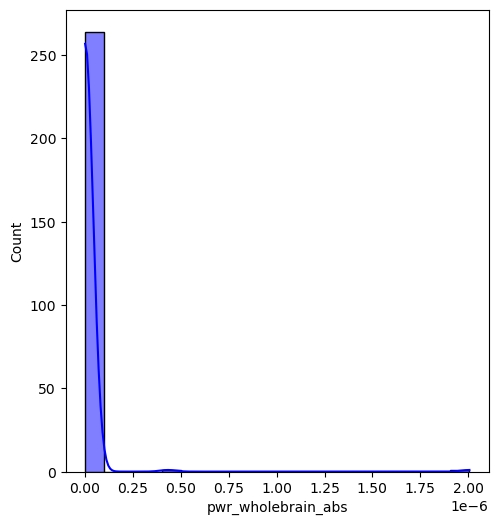

In [30]:
## plot distribution for EEG df

# Plot the distribution of the log_psd values in the EEG dataframe before and after 


fig = plt.figure(figsize=(12,6))

subplot1 = fig.add_subplot(121)
# Before 
sns.histplot(eeg_df['pwr_wholebrain_abs'], bins=20, kde=True, color='blue', alpha=0.5, ax=subplot1)


# Transform the data using a log transformation
eeg_df['log_pwr_frontal_abs'] = np.log(eeg_df['pwr_frontal_pwr_wholebrain_absabs'])

# Plot the distribution again bseide the before the transformation

subplot2 = fig.add_subplot(122)

sns.histplot(eeg_df['log_pwr_frontal_abs'], bins=20, kde=True, color='red', alpha=0.5, ax=subplot2)

In [31]:
# Merge EEG and Alpha band PSD dataframes
eeg_df

,subject,l_index,l_index_frontal,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel,left,inter
0,0225F1,-0.046453,0.088593,3.663439e-10,2.868993e-10,0.457241,5.272254e-11,4.347554e-11,0.067564,0.080114,0.072860
1,1134M1,-0.007547,0.115560,1.593386e-10,1.471404e-10,0.720930,6.502456e-11,4.579948e-11,0.286197,0.086066,0.078460
2,1089P,-0.029460,0.007899,2.613709e-09,3.599794e-09,0.979151,3.547681e-10,4.772061e-10,0.134081,0.065513,0.062832
3,1093S2,-0.249435,-0.293126,1.461285e-09,1.489179e-09,0.997520,1.408988e-10,2.110417e-10,0.097750,0.086834,0.075982
4,0150P,0.022924,0.123707,8.971349e-10,9.544705e-10,0.388582,6.948319e-11,1.025387e-10,0.029862,0.087788,0.072266
...,...,...,...,...,...,...,...,...,...,...,...
261,1052F1,-0.105206,-0.107773,7.886120e-10,1.038034e-09,2.384579,5.684165e-11,6.272317e-11,0.180536,0.082768,0.075164
262,0181P,-0.063366,-0.237717,1.194480e-09,9.800027e-10,1.222747,1.109535e-10,8.128225e-11,0.111906,0.091486,0.066298
263,0186F1,0.010115,-0.026745,5.382477e-10,7.703584e-10,1.151608,6.402504e-11,8.846801e-11,0.141216,0.070379,0.066019
264,1195P,0.072508,0.090328,1.160423e-09,2.130191e-09,0.963561,1.068838e-10,1.738779e-10,0.087990,0.087257,0.069622


In [32]:
# Merge demographic data with EEG data
eeg_data = pd.merge(eeg_df, demo_df, on='subject', how='left')
eeg_data

,subject,l_index,l_index_frontal,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel,left,...,site,sex,asd,ndd,q1k_ID,group,age_group,fam_id,developmental_group,affected_group
0,0225F1,-0.046453,0.088593,3.663439e-10,2.868993e-10,0.457241,5.272254e-11,4.347554e-11,0.067564,0.080114,...,mni,male,0.0,control,NaN,father,adult,0225,adult,non-affected
1,1134M1,-0.007547,0.115560,1.593386e-10,1.471404e-10,0.720930,6.502456e-11,4.579948e-11,0.286197,0.086066,...,hsj,female,0.0,ndd,NaN,mother,adult,1134,adult,affected
2,1089P,-0.029460,0.007899,2.613709e-09,3.599794e-09,0.979151,3.547681e-10,4.772061e-10,0.134081,0.065513,...,hsj,female,1.0,ndd,NaN,proband,child,1089,child,asd
3,1093S2,-0.249435,-0.293126,1.461285e-09,1.489179e-09,0.997520,1.408988e-10,2.110417e-10,0.097750,0.086834,...,hsj,female,1.0,control,NaN,sibling,child,1093,child,asd
4,0150P,0.022924,0.123707,8.971349e-10,9.544705e-10,0.388582,6.948319e-11,1.025387e-10,0.029862,0.087788,...,hsj,male,1.0,ndd,NaN,proband,child,0150,child,asd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,1052F1,-0.105206,-0.107773,7.886120e-10,1.038034e-09,2.384579,5.684165e-11,6.272317e-11,0.180536,0.082768,...,hsj,male,0.0,control,NaN,father,adult,1052,adult,non-affected
262,0181P,-0.063366,-0.237717,1.194480e-09,9.800027e-10,1.222747,1.109535e-10,8.128225e-11,0.111906,0.091486,...,mni,male,0.0,ndd,NaN,proband,adult,0181,adult,affected
263,0186F1,0.010115,-0.026745,5.382477e-10,7.703584e-10,1.151608,6.402504e-11,8.846801e-11,0.141216,0.070379,...,mni,male,0.0,control,NaN,father,adult,0186,adult,non-affected
264,1195P,0.072508,0.090328,1.160423e-09,2.130191e-09,0.963561,1.068838e-10,1.738779e-10,0.087990,0.087257,...,hsj,male,1.0,ndd,NaN,proband,child,1195,child,asd


In [33]:
# Drop those with missing demographic data
eeg_data = eeg_data[eeg_data['eeg_age'].notna()]

In [34]:
eeg_data

,subject,l_index,l_index_frontal,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel,left,...,site,sex,asd,ndd,q1k_ID,group,age_group,fam_id,developmental_group,affected_group
0,0225F1,-0.046453,0.088593,3.663439e-10,2.868993e-10,0.457241,5.272254e-11,4.347554e-11,0.067564,0.080114,...,mni,male,0.0,control,NaN,father,adult,0225,adult,non-affected
1,1134M1,-0.007547,0.115560,1.593386e-10,1.471404e-10,0.720930,6.502456e-11,4.579948e-11,0.286197,0.086066,...,hsj,female,0.0,ndd,NaN,mother,adult,1134,adult,affected
2,1089P,-0.029460,0.007899,2.613709e-09,3.599794e-09,0.979151,3.547681e-10,4.772061e-10,0.134081,0.065513,...,hsj,female,1.0,ndd,NaN,proband,child,1089,child,asd
3,1093S2,-0.249435,-0.293126,1.461285e-09,1.489179e-09,0.997520,1.408988e-10,2.110417e-10,0.097750,0.086834,...,hsj,female,1.0,control,NaN,sibling,child,1093,child,asd
4,0150P,0.022924,0.123707,8.971349e-10,9.544705e-10,0.388582,6.948319e-11,1.025387e-10,0.029862,0.087788,...,hsj,male,1.0,ndd,NaN,proband,child,0150,child,asd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,1052F1,-0.105206,-0.107773,7.886120e-10,1.038034e-09,2.384579,5.684165e-11,6.272317e-11,0.180536,0.082768,...,hsj,male,0.0,control,NaN,father,adult,1052,adult,non-affected
262,0181P,-0.063366,-0.237717,1.194480e-09,9.800027e-10,1.222747,1.109535e-10,8.128225e-11,0.111906,0.091486,...,mni,male,0.0,ndd,NaN,proband,adult,0181,adult,affected
263,0186F1,0.010115,-0.026745,5.382477e-10,7.703584e-10,1.151608,6.402504e-11,8.846801e-11,0.141216,0.070379,...,mni,male,0.0,control,NaN,father,adult,0186,adult,non-affected
264,1195P,0.072508,0.090328,1.160423e-09,2.130191e-09,0.963561,1.068838e-10,1.738779e-10,0.087990,0.087257,...,hsj,male,1.0,ndd,NaN,proband,child,1195,child,asd


In [35]:
# Save the final EEG dataframe
eeg_data.to_csv(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/eeg/eeg_data.csv", index=False)